In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

from swarmbots.unit import Unit
from rendering import display_video

In [2]:
RENDER_WIDTH = 640
RENDER_HEIGHT = 480

In [21]:
env = mjcf.RootElement()

getattr(env.visual, 'global').offwidth = RENDER_WIDTH
getattr(env.visual, 'global').offheight = RENDER_HEIGHT

chequered = env.asset.add('texture', type='2d', builtin='checker', width=300,
                            height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = env.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[5, 5], reflectance=.2)
env.worldbody.add('geom', type='plane', size=[2, 2, .1], material=grid)

for x in [-2, 2]:
  env.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])

unit1 = Unit(0.1, 0.2, 0.025, np.pi/3)

spawn_site = env.worldbody.add('site', pos=[0, 0, 2.11], euler=[0, np.pi, 0])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site.attach(unit1.model) # .add('freejoint')
# # # print(env.to_xml_string())

# unit2 = Unit(0.1, 0.2, 0.025, np.pi/4)
# # 
# spawn_site = env.worldbody.add('site', pos=[0, 0, 1.5], euler=[0, 0, 0]) #, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
# # spawn_site = env.worldbody.add('site', pos=[0, 0, 0.2], euler=[0, 0, 0]) #, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
# spawn_site.attach(unit2.model).add('freejoint')
# env.equality.add(
#     'weld', 
#     body1=f'unnamed_model/unnamed_model/{unit1.name}-leg0-foot', 
#     body2=f'unnamed_model_1/unnamed_model/{unit2.name}-leg0-foot',
#     torquescale=10000
# )
# print(env.worldbody.find_all('body'))

# cam = env.worldbody.add('camera', mode='targetbody', target=f'unnamed_model/unnamed_model/{unit1.name}-leg0', pos=[0, 1.5, 1])
cam = env.worldbody.add('camera', mode='targetbody', target=f'unnamed_model/unnamed_model/{unit1.name}-leg0', pos=[0, 0, 0.1])



# env.to_xml_string()

for geom in env.worldbody.find_all('geom'):
    if False and np.isclose(geom.size[0], 0.0275):
        print(geom.parent.to_xml_string())

In [22]:
physics = mjcf.Physics.from_mjcf_model(env)
print(physics.data.eq_active)
PIL.Image.fromarray(physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT, camera_id=0))


In [31]:
duration = 10   # (Seconds)
framerate = 30  # (Hz)
video = []
 
last_switch = 0

# Simulate, saving video frames and torso locations.
physics.reset()
while physics.data.time < duration:
    physics.set_control([0] * 0 + [np.sin(physics.data.time) * 13, np.cos(physics.data.time) * 13] * 3 + [0] * 0)
    # physics.set_control([0] * 0 + [10, 10] * 3 + [0] * 0)
    physics.step()
    
    # Save video frames.
    if len(video) < physics.data.time * framerate:
        pixels = physics.render(width=RENDER_WIDTH, height=RENDER_HEIGHT, camera_id=0)
        video.append(pixels.copy())

    # if (physics.data.time - last_switch) > 0.5:
    #   last_switch = physics.data.time
    #   for i in range(4):
    #       physics.data.eq_active[i] = 1 - physics.data.eq_active[i]
    #   print(last_switch)
    
    # if physics.data.time > 3:
    #     physics.data.eq_active[0] = 0
    
    # if physics.data.time > 3.2:
    #     physics.data.eq_active[0] = 1
    
 

display_video(video, framerate)

In [14]:
len(video)

In [48]:
import mujoco

XML=r"""
<mujoco>
  <worldbody>
    <body>
      <freejoint/>
      <geom type="sphere" size="1" />
    </body>
  </worldbody>
</mujoco>
"""

ASSETS=dict()

model = mujoco.MjModel.from_xml_string(env.to_xml_string(), ASSETS)
data = mujoco.MjData(model)

model.eq(0)

-9.227869875015472e-05
[ 6.05947753e-04 -3.03595444e-04 -8.00633793e-07  2.93556255e-07
 -3.60580783e-05  5.33712089e-04 -9.74655573e-04  1.71913283e-03
  5.28240317e-04 -3.12191049e-04 -7.61409450e-07  3.67321605e-07
 -3.25304198e-05  5.35891770e-04 -9.74465077e-04  1.80970549e-03]


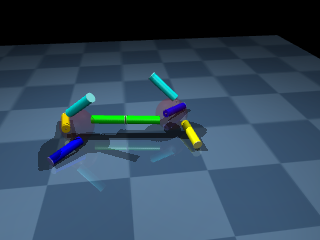

In [7]:
from swarmbots.swarm_bot_env import SwarmBotEnv

sbenv = SwarmBotEnv(physics_steps_per_step=10, hip_range=np.pi/4)

for _ in range(1000):
    sbenv.physics.set_control([-1] * 16)
    sbenv.physics.step()
print(sbenv.physics.data.xpos[:, 0].mean())
print(sbenv.physics.data.actuator_velocity)
PIL.Image.fromarray(sbenv.render())
# 
# duration = 10   # (Seconds)
# framerate = 50  # (Hz)
# video = []
#  
# sbenv.reset()
# done = False
# while not done:
#     obs, reward, term, trunc, info = sbenv.step([0] * 16)
#     
#     pixels = sbenv.render()
#     video.append(pixels.copy())
# 
#     done = term or trunc
#     
#  
# 
# display_video(video, framerate)